# Correlación entre población y viviendas sin servicio

Matriz de correlación de Pearson para `POBLACION`, `VSS Urbano`, `VSS Rural` y `VSS Total` en `datos/Municipio con ICEE menor a 95 por ciento.csv`.

Pearson mide si dos columnas suben juntas. Va de −1 a 1. Cerca de 1, se mueven en el mismo sentido. Cerca de 0, no se acompañan. El cálculo usa los 744 municipios del archivo, incluidas las 19 áreas no municipalizadas. Las cuatro columnas están completas en todas las filas.

744 municipios
VSS Total es la suma de VSS Urbano y VSS Rural: True


,POBLACION,VSS Urbano,VSS Rural,VSS Total
POBLACION,1.000,0.957,0.089,0.928
VSS Urbano,0.957,1.000,0.023,0.948
VSS Rural,0.089,0.023,1.000,0.341
VSS Total,0.928,0.948,0.341,1.000


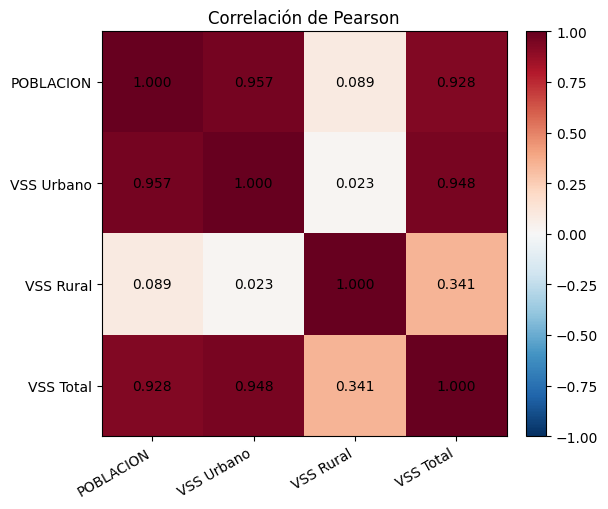

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

archivo = Path("datos") / "Municipio con ICEE menor a 95 por ciento.csv"
columnas = ["POBLACION", "VSS Urbano", "VSS Rural", "VSS Total"]

df = pd.read_csv(archivo, sep=";", decimal=",", encoding="utf-8")
matriz = df[columnas].corr(method="pearson")

print(f"{len(df)} municipios")
print("VSS Total es la suma de VSS Urbano y VSS Rural:",
      bool(((df["VSS Urbano"] + df["VSS Rural"] - df["VSS Total"]).abs() < 1e-6).all()))

display(matriz.round(3))

fig, ax = plt.subplots(figsize=(6.2, 5.2))
imagen = ax.imshow(matriz, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(columnas)), columnas, rotation=30, ha="right")
ax.set_yticks(range(len(columnas)), columnas)
for i in range(len(columnas)):
    for j in range(len(columnas)):
        ax.text(j, i, f"{matriz.iloc[i, j]:.3f}", ha="center", va="center", color="black")
ax.set_title("Correlación de Pearson")
fig.colorbar(imagen, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()


## Lectura

`VSS Urbano` y `POBLACION` se mueven casi juntas (0,957). `VSS Total` también acompaña a la población (0,928), porque el total está dominado por el componente urbano: su correlación con `VSS Urbano` es 0,948.

`VSS Rural` va por otro lado. Con la población queda en 0,089 y con `VSS Urbano` en 0,023. Con `VSS Total` sube a 0,341 porque el rural es una parte de esa suma, no porque el déficit rural crezca con el tamaño del municipio.

En los 744 municipios, `VSS Total` es exactamente `VSS Urbano` más `VSS Rural`. Poner las tres series juntas en un mismo cálculo cuenta el déficit de viviendas más de una vez.

## Solo categoría 6

La misma matriz, restringida a los municipios con `CATEGORIA` igual a 6. Son 671 filas. Las áreas no municipalizadas no tienen categoría, así que quedan fuera. Las cuatro columnas siguen completas y `VSS Total` sigue siendo la suma de urbano y rural.

671 municipios de categoría 6
VSS Total es la suma de VSS Urbano y VSS Rural: True


,POBLACION,VSS Urbano,VSS Rural,VSS Total
POBLACION,1.000,0.418,0.630,0.711
VSS Urbano,0.418,1.000,0.131,0.492
VSS Rural,0.630,0.131,1.000,0.927
VSS Total,0.711,0.492,0.927,1.000


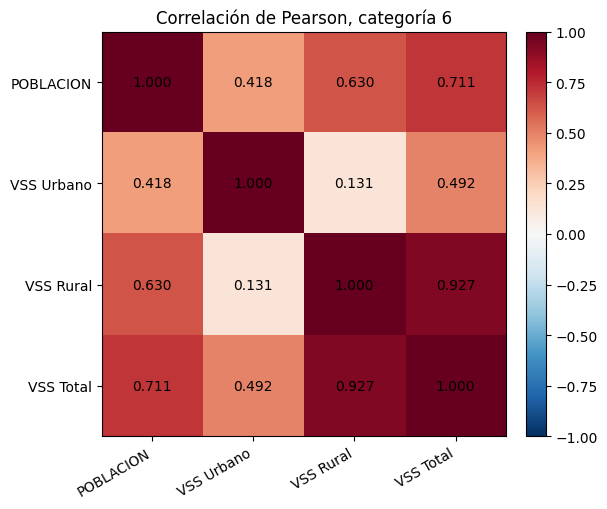

In [2]:
categoria_6 = df[df["CATEGORIA"].astype("string").str.strip() == "6"]
matriz_6 = categoria_6[columnas].corr(method="pearson")

print(f"{len(categoria_6)} municipios de categoría 6")
print("VSS Total es la suma de VSS Urbano y VSS Rural:",
      bool(((categoria_6["VSS Urbano"] + categoria_6["VSS Rural"] - categoria_6["VSS Total"]).abs() < 1e-6).all()))

display(matriz_6.round(3))

fig, ax = plt.subplots(figsize=(6.2, 5.2))
imagen = ax.imshow(matriz_6, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(columnas)), columnas, rotation=30, ha="right")
ax.set_yticks(range(len(columnas)), columnas)
for i in range(len(columnas)):
    for j in range(len(columnas)):
        ax.text(j, i, f"{matriz_6.iloc[i, j]:.3f}", ha="center", va="center", color="black")
ax.set_title("Correlación de Pearson, categoría 6")
fig.colorbar(imagen, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()


### Lectura para la categoría 6

En estos 671 municipios la población ya no se mueve con el déficit urbano. `POBLACION` y `VSS Urbano` quedan en 0,418. La relación fuerte pasa al campo: `POBLACION` y `VSS Rural` quedan en 0,630, y `VSS Rural` con `VSS Total` en 0,927. El total acompaña a la población en 0,711.

`VSS Urbano` y `VSS Rural` siguen casi desligados (0,131). En la categoría 6 el tamaño del municipio se refleja sobre todo en las viviendas rurales sin servicio, y ese componente es el que arrastra a `VSS Total`.